In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

import warnings 
warnings.filterwarnings("ignore")

df = pd.read_csv('../data/Preprocessed.csv')
df.head()

,Age,Number of Dependents,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,...,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check,Churn Label
0,78,0,34.023810,-118.156582,68701,0,1,0.00,8,39.65,...,0,1,0,0,0,0,1,0,0,1
1,74,1,34.044271,-118.185237,55668,1,8,48.85,17,80.65,...,0,0,0,1,0,0,1,1,0,1
2,71,3,34.108833,-118.229715,47534,0,18,11.33,52,95.45,...,1,1,1,1,0,0,1,0,0,1
3,78,1,33.936291,-118.332639,27778,1,25,19.76,12,98.50,...,1,1,0,1,0,0,1,0,0,1
4,80,1,33.972119,-118.020188,26265,1,37,6.33,14,76.50,...,0,0,0,1,0,0,1,0,0,1


In [3]:
X_cluster = df.drop(columns=["Churn Label"])

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

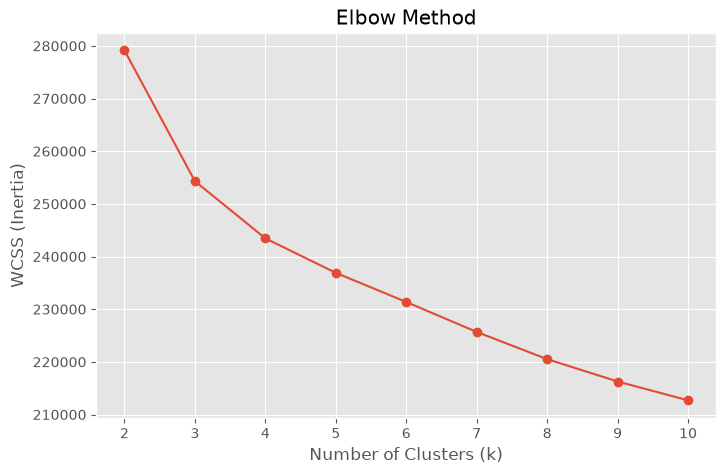

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [6]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print(f"k={k}: {score:.4f}")

k=2: 0.1247
k=3: 0.1188
k=4: 0.1112
k=5: 0.1075
k=6: 0.0843
k=7: 0.0818
k=8: 0.0817
k=9: 0.0790
k=10: 0.0785


In [7]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [8]:
df["Cluster"].value_counts().sort_index()

Cluster
0    5512
1    1531
Name: count, dtype: int64

In [9]:
(df["Cluster"].value_counts(normalize=True) * 100).sort_index()

Cluster
0    78.262104
1    21.737896
Name: proportion, dtype: float64

In [10]:
pd.crosstab(
    df["Cluster"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,0,1
Cluster,,
0,68.160377,31.839623
1,92.553886,7.446114


In [11]:
df.groupby("Cluster")[[
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges",
    
]].mean()

,Tenure in Months,Monthly Charge,Total Charges
Cluster,,,
0,32.911103,76.880860,2729.948657
1,30.499020,21.129523,661.821189


In [12]:
numerical_features = [
    "Age",
    "Number of Dependents",
    "Population",
    "Number of Referrals",
    "Tenure in Months",
    "Avg Monthly Long Distance Charges",
    "Avg Monthly GB Download",
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Satisfaction Score"
]

cluster_summary = df.groupby("Cluster")[numerical_features].mean().round(2)

cluster_summary

,Age,Number of Dependents,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Satisfaction Score
Cluster,,,,,,,,,,,,,
0,47.55,0.39,22285.72,1.89,32.91,22.41,26.19,76.88,2729.95,2.05,8.75,743.85,3.08
1,42.76,0.75,21613.54,2.17,30.50,24.95,0.08,21.13,661.82,1.65,0.07,767.98,3.85


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 47 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Number of Dependents               7043 non-null   int64  
 2   Latitude                           7043 non-null   float64
 3   Longitude                          7043 non-null   float64
 4   Population                         7043 non-null   int64  
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Avg Monthly Long Distance Charges  7043 non-null   float64
 8   Avg Monthly GB Download            7043 non-null   int64  
 9   Monthly Charge                     7043 non-null   float64
 10  Total Charges                      7043 non-null   float64
 11  Total Refunds                      7043 non-null   float64
 12  Tot

In [14]:
cluster_std = df.groupby("Cluster")[numerical_features].std().round(2)

cluster_std

,Age,Number of Dependents,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Satisfaction Score
Cluster,,,,,,,,,,,,,
0,17.26,0.90,21221.48,2.95,24.58,15.76,19.59,21.9,2355.24,8.08,28.07,856.22,1.21
1,14.14,1.12,20900.20,3.18,24.32,14.09,1.52,2.4,554.66,7.23,1.84,811.29,0.97


In [15]:
binary_features = [
    "Gender_Male",
    "Under 30_Yes",
    "Senior Citizen_Yes",
    "Married_Yes",
    "Dependents_Yes",
    "Referred a Friend_Yes",
    "Offer_Offer A",
    "Offer_Offer B",
    "Offer_Offer C",
    "Offer_Offer D",
    "Offer_Offer E",
    "Phone Service_Yes",
    "Multiple Lines_Yes",
    "Internet Service_Yes",
    "Internet Type_DSL",
    "Internet Type_Fiber Optic",
    "Internet Type_No Internet Service",
    "Online Security_Yes",
    "Online Backup_Yes",
    "Device Protection Plan_Yes",
    "Premium Tech Support_Yes",
    "Streaming TV_Yes",
    "Streaming Movies_Yes",
    "Streaming Music_Yes",
    "Unlimited Data_Yes",
    "Contract_One Year",
    "Contract_Two Year",
    "Paperless Billing_Yes",
    "Payment Method_Credit Card",
    "Payment Method_Mailed Check"
]

binary_summary = (
    df.groupby("Cluster")[binary_features]
      .mean()
      .multiply(100)
      .round(2)
)

binary_summary

,Gender_Male,Under 30_Yes,Senior Citizen_Yes,Married_Yes,Dependents_Yes,Referred a Friend_Yes,Offer_Offer A,Offer_Offer B,Offer_Offer C,Offer_Offer D,...,Premium Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
Cluster,,,,,,,,,,,,,,,,,,,,,
0,50.31,19.14,19.78,48.33,19.27,45.86,7.76,12.01,6.06,7.93,...,37.08,49.11,49.56,45.14,86.08,21.48,22.51,67.56,32.96,4.39
1,51.08,22.60,3.40,48.20,36.90,45.33,6.01,10.58,5.29,10.78,...,0.00,0.00,0.00,0.00,0.00,23.91,41.93,29.20,60.88,9.34


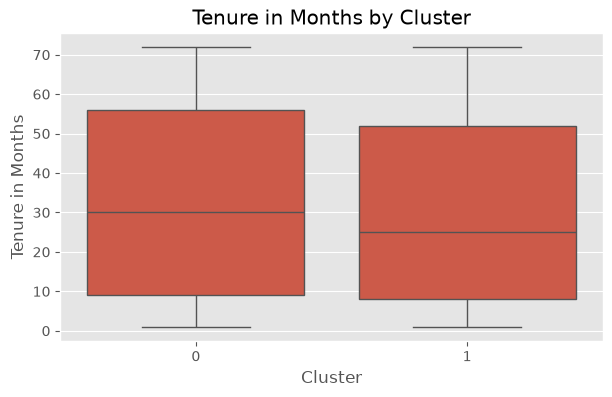

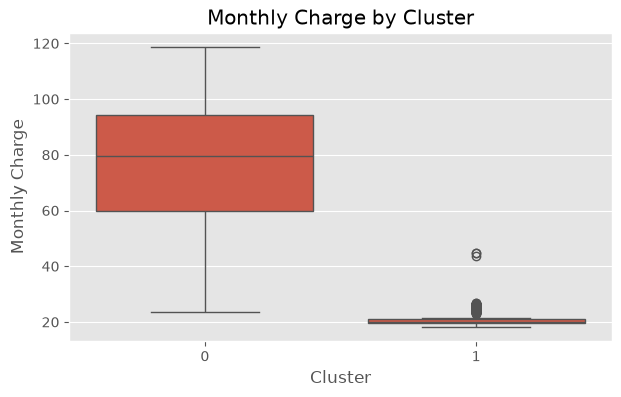

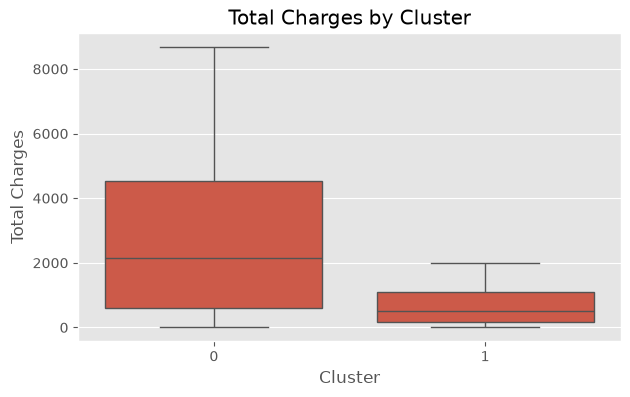

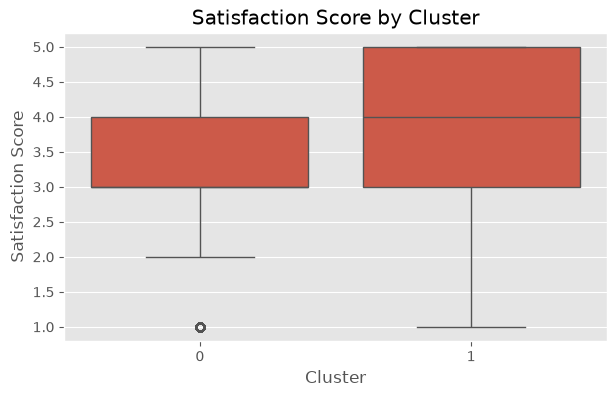

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges",
    "Satisfaction Score"
]

for feature in features:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="Cluster", y=feature)
    plt.title(f"{feature} by Cluster")
    plt.show()

In [17]:
binary_features = [
    "Gender_Male",
    "Under 30_Yes",
    "Senior Citizen_Yes",
    "Married_Yes",
    "Dependents_Yes",
    "Referred a Friend_Yes",
    "Offer_Offer A",
    "Offer_Offer B",
    "Offer_Offer C",
    "Offer_Offer D",
    "Offer_Offer E",
    "Phone Service_Yes",
    "Multiple Lines_Yes",
    "Internet Service_Yes",
    "Internet Type_DSL",
    "Internet Type_Fiber Optic",
    "Internet Type_No Internet Service",
    "Online Security_Yes",
    "Online Backup_Yes",
    "Device Protection Plan_Yes",
    "Premium Tech Support_Yes",
    "Streaming TV_Yes",
    "Streaming Movies_Yes",
    "Streaming Music_Yes",
    "Unlimited Data_Yes",
    "Contract_One Year",
    "Contract_Two Year",
    "Paperless Billing_Yes",
    "Payment Method_Credit Card",
    "Payment Method_Mailed Check"
]

binary_summary = (
    df.groupby("Cluster")[binary_features]
      .mean()
      .multiply(100)
      .round(2)
)

binary_summary

,Gender_Male,Under 30_Yes,Senior Citizen_Yes,Married_Yes,Dependents_Yes,Referred a Friend_Yes,Offer_Offer A,Offer_Offer B,Offer_Offer C,Offer_Offer D,...,Premium Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
Cluster,,,,,,,,,,,,,,,,,,,,,
0,50.31,19.14,19.78,48.33,19.27,45.86,7.76,12.01,6.06,7.93,...,37.08,49.11,49.56,45.14,86.08,21.48,22.51,67.56,32.96,4.39
1,51.08,22.60,3.40,48.20,36.90,45.33,6.01,10.58,5.29,10.78,...,0.00,0.00,0.00,0.00,0.00,23.91,41.93,29.20,60.88,9.34


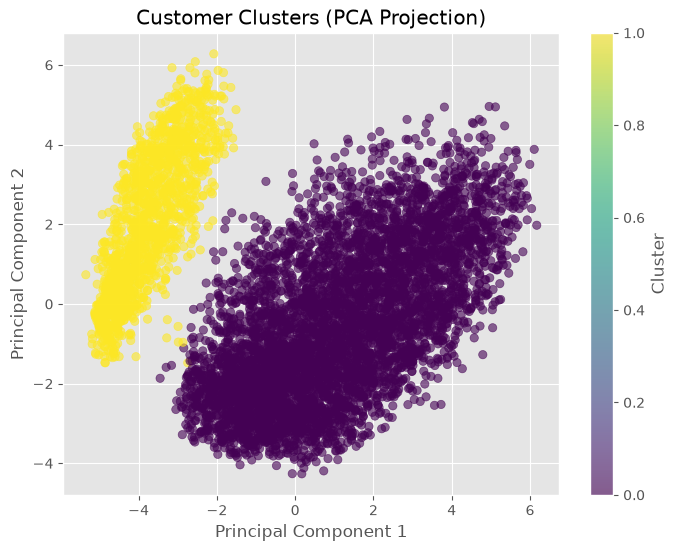

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Clusters (PCA Projection)")
plt.colorbar(label="Cluster")
plt.show()

In [19]:
comparison = df.groupby("Cluster").agg({
    "Tenure in Months":"mean",
    "Monthly Charge":"mean",
    "Total Charges":"mean",
    "Satisfaction Score":"mean",
    "Churn Label":"mean"
})

comparison["Churn Label"] *= 100

comparison.round(2)

,Tenure in Months,Monthly Charge,Total Charges,Satisfaction Score,Churn Label
Cluster,,,,,
0,32.91,76.88,2729.95,3.08,31.84
1,30.50,21.13,661.82,3.85,7.45


In [20]:
import joblib

joblib.dump(kmeans, "../models/kmeans.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [21]:
cluster0_df = df[df["Cluster"] == 0].copy()
cluster1_df = df[df["Cluster"] == 1].copy()

cluster0_df.to_csv("../data/cluster0.csv", index=False)
cluster1_df.to_csv("../data/cluster1.csv", index=False)